In [71]:
import matplotlib.pyplot as plt
import matplotlib.ticker as tkr
import numpy as np
import pandas as pd
import math
#import seaborn as sns
from sklearn.cluster import KMeans
import matplotlib.ticker as ticker
from matplotlib import rc

In [72]:
# Define a custom grouping function
  
col_names=['dzonenr', 'duration', 'extents']

# Step 1: Read the CSV file into a Pandas DataFrame
#df = pd.read_csv('/home/surbhi/measurements/HM-Hybrid/cache/bg-cleaning/4K/so-far-cache0-8.35am.log', sep=' ', names=col_names)
#df = pd.read_csv('/home/surbhi/measurements/HM-Hybrid/cache/bg-cleaning/4K/data-zones-list', sep=' ', names=col_names)
#df = pd.read_csv('/home/surbhi/measurements/worst_case/HM-Hybrid/4KB/90-10-LBA/90Util/15Zones.WakeOne/data-zone-list', sep=' ', names=col_names)
df = pd.read_csv('/home/surbhi/measurements/worst_case/HM-Hybrid/4KB/90-10-LBA/90Util/15Zones.WakeOne/data-zone-list', sep=' ', names=col_names)
df['duration'] = df['duration']/1e3
df['cumulative_duration'] = df['duration'].cumsum()
 

In [73]:
df.describe()


,dzonenr,duration,extents,cumulative_duration
count,144486.000000,144486.000000,144486.000000,144486.000000
mean,14332.617195,2.645589,486774.561245,196243.529692
std,8276.889345,0.331725,19135.711358,108631.196606
min,0.000000,1.665000,471864.000000,2.768000
25%,7191.000000,2.467000,471864.000000,104145.747500
50%,14323.500000,2.571000,471880.000000,197694.521500
75%,21494.750000,2.689000,503560.000000,290006.570750
max,28671.000000,10.457000,996152.000000,382250.631000


In [74]:
total = df['duration'].sum() / (60 ** 2)
print(f"Total duration: {total} hours")

Total duration: 106.18073083333331 hours


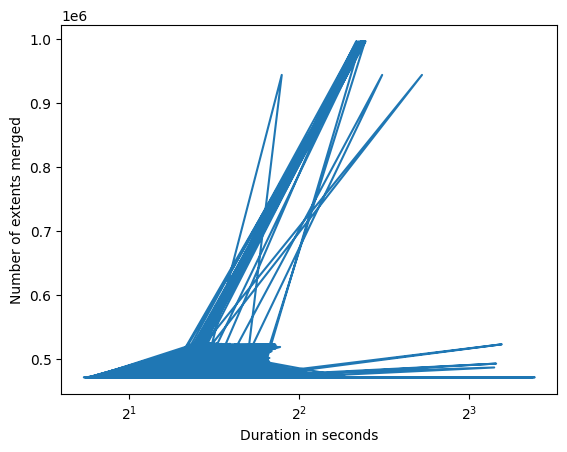

In [75]:
plt.ylabel("Number of extents merged")
plt.xlabel("Duration in seconds")
plt.plot(df['duration'], df['extents'])
plt.xscale('log', base=2)
plt.show()

Text(0, 0.5, 'CDF')

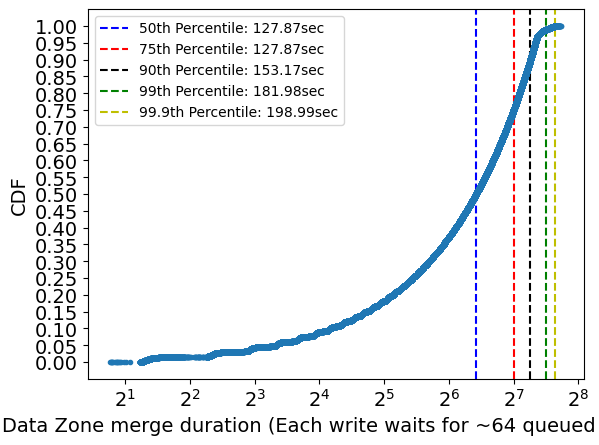

In [79]:
# Create a group label for every 32 rows
df['group'] = (df.index // 64)
# Apply cumsum to each group
df['cumulative_duration'] = df.groupby('group')['duration'].cumsum()

data_sorted = np.sort(df['cumulative_duration'])
# Step 2: Compute the Cumulative Distribution Function (CDF)
cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
# Step 3: Calculate 90th and 99th percentiles
p50 = np.percentile(data_sorted, 50)
p75 = np.percentile(data_sorted, 75)
p90 = np.percentile(data_sorted, 90)
p99 = np.percentile(data_sorted, 99)
p999 = np.percentile(data_sorted, 99.9)
# Step 4: Plot the CDF
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
# Mark the 90th and 99th percentiles with vertical lines
plt.axvline(x=p50, color='blue', linestyle='--', label='50th Percentile: ' + str(round(p75, 2)) + "sec" )
plt.axvline(x=p75, color='r', linestyle='--', label='75th Percentile: ' + str(round(p75, 2)) + "sec" )
plt.axvline(x=p90, color='black', linestyle='--', label='90th Percentile: ' + str(round(p90, 2)) + "sec" )
plt.axvline(x=p99, color='g', linestyle='--', label='99th Percentile: ' + str(round(p99, 2)) + "sec")
plt.axvline(x=p999, color='y', linestyle='--', label='99.9th Percentile: ' + str(round(p999, 2)) + "sec")
plt.xscale('log', base=2)

plt.legend()
plt.yticks(np.arange(0, 1.1, 0.05))
plt.plot(data_sorted, cdf, marker='.', linestyle='none')
plt.xlabel('Data Zone merge duration (Each write waits for ~64 queued writes)', fontsize=14)
plt.ylabel('CDF', fontsize=14)


Text(0, 0.5, 'CDF')

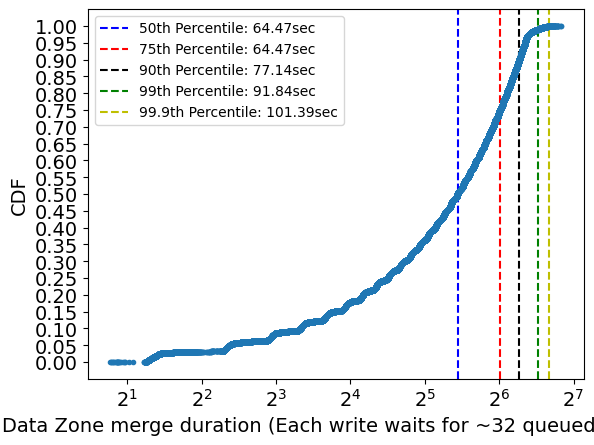

In [85]:
df['group'] = (df.index // 32)
# Apply cumsum to each group
df['cumulative_duration'] = df.groupby('group')['duration'].cumsum()

data_sorted = np.sort(df['cumulative_duration'])
# Step 2: Compute the Cumulative Distribution Function (CDF)
cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
# Step 3: Calculate 90th and 99th percentiles
p50 = np.percentile(data_sorted, 50)
p75 = np.percentile(data_sorted, 75)
p90 = np.percentile(data_sorted, 90)
p99 = np.percentile(data_sorted, 99)
p999 = np.percentile(data_sorted, 99.9)
# Step 4: Plot the CDF
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
# Mark the 90th and 99th percentiles with vertical lines
plt.axvline(x=p50, color='blue', linestyle='--', label='50th Percentile: ' + str(round(p75, 2)) + "sec" )
plt.axvline(x=p75, color='r', linestyle='--', label='75th Percentile: ' + str(round(p75, 2)) + "sec" )
plt.axvline(x=p90, color='black', linestyle='--', label='90th Percentile: ' + str(round(p90, 2)) + "sec" )
plt.axvline(x=p99, color='g', linestyle='--', label='99th Percentile: ' + str(round(p99, 2)) + "sec")
plt.axvline(x=p999, color='y', linestyle='--', label='99.9th Percentile: ' + str(round(p999, 2)) + "sec")
plt.xscale('log', base=2)

plt.legend()
plt.yticks(np.arange(0, 1.1, 0.05))
plt.plot(data_sorted, cdf, marker='.', linestyle='none')
plt.xlabel('Data Zone merge duration (Each write waits for ~32 queued writes)', fontsize=14)
plt.ylabel('CDF', fontsize=14)

Text(0, 0.5, 'CDF')

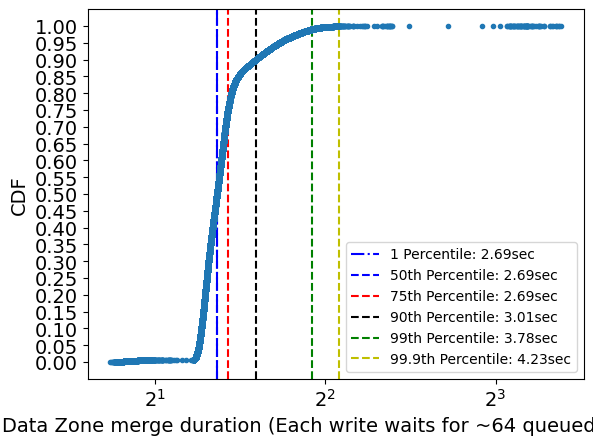

In [86]:
df['group'] = (df.index )
# Apply cumsum to each group
df['cumulative_duration'] = df.groupby('group')['duration'].cumsum()

data_sorted = np.sort(df['cumulative_duration'])
# Step 2: Compute the Cumulative Distribution Function (CDF)
cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
# Step 3: Calculate 90th and 99th percentiles
p1 = np.percentile(data_sorted, 1)
p50 = np.percentile(data_sorted, 50)
p75 = np.percentile(data_sorted, 75)
p90 = np.percentile(data_sorted, 90)
p99 = np.percentile(data_sorted, 99)
p999 = np.percentile(data_sorted, 99.9)
# Step 4: Plot the CDF
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
# Mark the 90th and 99th percentiles with vertical lines
plt.axvline(x=p50, color='blue', linestyle='-.', label='1 Percentile: ' + str(round(p75, 2)) + "sec" )
plt.axvline(x=p50, color='blue', linestyle='--', label='50th Percentile: ' + str(round(p75, 2)) + "sec" )
plt.axvline(x=p75, color='r', linestyle='--', label='75th Percentile: ' + str(round(p75, 2)) + "sec" )
plt.axvline(x=p90, color='black', linestyle='--', label='90th Percentile: ' + str(round(p90, 2)) + "sec" )
plt.axvline(x=p99, color='g', linestyle='--', label='99th Percentile: ' + str(round(p99, 2)) + "sec")
plt.axvline(x=p999, color='y', linestyle='--', label='99.9th Percentile: ' + str(round(p999, 2)) + "sec")
plt.xscale('log', base=2)

plt.legend()
plt.yticks(np.arange(0, 1.1, 0.05))
plt.plot(data_sorted, cdf, marker='.', linestyle='none')
plt.xlabel('Data Zone merge duration (Each write waits for ~64 queued writes)', fontsize=14)
plt.ylabel('CDF', fontsize=14)